<a href="https://colab.research.google.com/github/csabdoorehman/Used-Car-Valuation-Engine/blob/main/car_valuation_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('used_cars.csv')
df.head()

,year,mileage,engine_size,brand,transmission,price
0,2019,45000,2.0,Toyota,Automatic,22500
1,2017,68000,1.6,Ford,Manual,13200
2,2021,18000,3.0,BMW,Automatic,42000
3,2015,95000,2.4,Honda,Automatic,11800
4,2020,31000,2.0,Mercedes,Automatic,36500


In [ ]:
print("--- Data Info ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
df.info()

--- Data Info ---
Rows: 20, Columns: 6

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          20 non-null     int64  
 1   mileage       20 non-null     int64  
 2   engine_size   20 non-null     float64
 3   brand         20 non-null     object 
 4   transmission  20 non-null     object 
 5   price         20 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.1+ KB


In [ ]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
year            0
mileage         0
engine_size     0
brand           0
transmission    0
price           0
dtype: int64


In [ ]:
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
              year        mileage  engine_size         price
count    20.000000      20.000000    20.000000     20.000000
mean   2018.150000   56150.000000     2.210000  24035.000000
std       2.739093   34871.606607     0.435165  12801.532597
min    2013.000000    8000.000000     1.600000   6500.000000
25%    2016.000000   30000.000000     2.000000  12925.000000
50%    2018.500000   46500.000000     2.000000  21150.000000
75%    2020.000000   84500.000000     2.500000  34625.000000
max    2023.000000  125000.000000     3.000000  49500.000000


In [ ]:
print("\n--- Categorical Feature Value Counts ---")
print("Brands:", df['brand'].value_counts().to_dict())
print("Transmissions:", df['transmission'].value_counts().to_dict())


--- Categorical Feature Value Counts ---
Brands: {'Toyota': 4, 'Ford': 4, 'BMW': 4, 'Honda': 4, 'Mercedes': 4}
Transmissions: {'Automatic': 15, 'Manual': 5}


In [ ]:
CURRENT_YEAR = 2026
df['car_age'] = CURRENT_YEAR - df['year']

In [ ]:
df_model = df.drop(columns=['year'])

In [ ]:
X = df_model.drop(columns=['price'])
y = df_model['price']

In [ ]:
numeric_features = ['car_age', 'mileage', 'engine_size']
categorical_features = ['brand', 'transmission']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

In [ ]:
X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed_df,
    y,
    test_size=0.2,
    random_state=42
)

print("--- Preprocessing & Split Complete ---")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print("\nEncoded Feature Matrix Sample:")
X_train.head()

--- Preprocessing & Split Complete ---
X_train Shape: (16, 8)
X_test Shape:  (4, 8)

Encoded Feature Matrix Sample:


,car_age,mileage,engine_size,brand_Ford,brand_Honda,brand_Mercedes,brand_Toyota,transmission_Manual
8,1.554460,1.584353,-0.966648,0.0,1.0,0.0,0.0,1.0
5,0.056185,-0.122100,-0.966648,0.0,0.0,0.0,1.0,1.0
11,1.929028,2.025677,-0.495112,1.0,0.0,0.0,0.0,1.0
3,1.179891,1.143029,0.447959,0.0,1.0,0.0,0.0,0.0
18,-0.318383,-0.445737,0.447959,0.0,1.0,0.0,0.0,0.0


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
)

In [ ]:
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    # Generate predictions on test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": model_name,
        "RMSE ($)": round(rmse, 2),
        "MAE ($)": round(mae, 2),
        "R² Score": round(r2, 4),
    }

In [ ]:
rf_results = evaluate_model(
    rf_model, X_test, y_test, model_name="Random Forest"
)
xgb_results = evaluate_model(xgb_model, X_test, y_test, model_name="XGBoost")

In [ ]:
comparison_df = pd.DataFrame([rf_results, xgb_results])

print("--- Model Performance Comparison ---")
print(comparison_df.to_string(index=False))

--- Model Performance Comparison ---
        Model  RMSE ($)  MAE ($)  R² Score
Random Forest   7390.76  4065.75    0.1139
      XGBoost   7459.18  4801.87    0.0974


In [ ]:
importances = xgb_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importances}
).sort_values(by="Importance", ascending=False)

print("\n--- Top Price Drivers (XGBoost Feature Importance) ---")
print(feature_importance_df.to_string(index=False))


--- Top Price Drivers (XGBoost Feature Importance) ---
            Feature  Importance
            mileage    0.746776
            car_age    0.108937
        engine_size    0.092593
     brand_Mercedes    0.022344
        brand_Honda    0.015100
transmission_Manual    0.007443
       brand_Toyota    0.005339
         brand_Ford    0.001468


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

In [ ]:
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

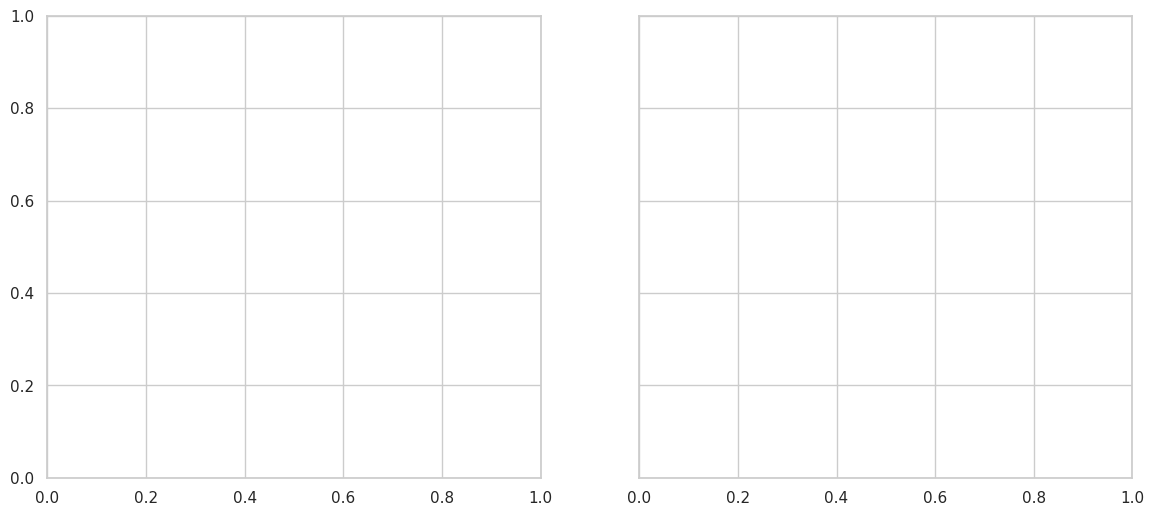

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

In [ ]:
sns.scatterplot(
    x=y_test, y=rf_preds, ax=axes[0], color="#2b5c8f", alpha=0.8, s=70
)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Prediction",
)
axes[0].set_title("Random Forest: Actual vs Predicted", fontsize=12, pad=10)
axes[0].set_xlabel("Actual Price ($)", fontsize=11)
axes[0].set_ylabel("Predicted Price ($)", fontsize=11)
axes[0].legend()

# XGBoost Scatter Plot
sns.scatterplot(
    x=y_test, y=xgb_preds, ax=axes[1], color="#d95f02", alpha=0.8, s=70
)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Prediction",
)
axes[1].set_title("XGBoost: Actual vs Predicted", fontsize=12, pad=10)
axes[1].set_xlabel("Actual Price ($)", fontsize=11)
axes[1].legend()

plt.suptitle(
    "Model Predictions vs Ideal Line ($y = x$)", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_5367/1444054168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


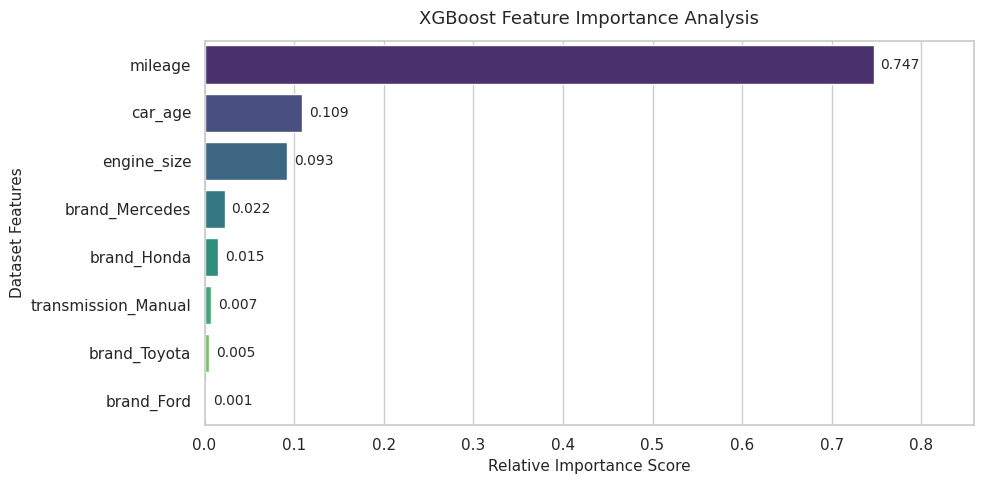

In [ ]:
importance_df = pd.DataFrame(
    {"Feature": X_train.columns, "Importance": xgb_model.feature_importances_}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
palette = sns.color_palette("viridis", len(importance_df))

ax = sns.barplot(
    data=importance_df, x="Importance", y="Feature", palette=palette
)

# Annotate values on each bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        xytext=(5, 0),
        textcoords="offset points",
        fontsize=10,
    )

plt.title("XGBoost Feature Importance Analysis", fontsize=13, pad=12)
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Dataset Features", fontsize=11)
plt.xlim(0, importance_df["Importance"].max() * 1.15)  # Leave room for labels
plt.tight_layout()
plt.show()

In [ ]:
CURRENT_YEAR = 2026
df["car_age"] = CURRENT_YEAR - df["year"]

X = df.drop(columns=["price", "year"])
y = df["price"]

numeric_features = ["car_age", "mileage", "engine_size"]
categorical_features = ["brand", "transmission"]

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False),
            categorical_features,
        ),
    ]
)

In [ ]:
winning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
            ),
        ),
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
winning_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['car_age', 'mileage',
                                                   'engine_size']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['brand', 'transmission'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
model_filename = "used_car_xgboost_pipeline.joblib"
joblib.dump(winning_pipeline, model_filename)

print(f"Model pipeline saved successfully as '{model_filename}'")

Model pipeline saved successfully as 'used_car_xgboost_pipeline.joblib'


In [ ]:
loaded_model = joblib.load(model_filename)

In [ ]:
single_user_input = {
    "car_age": 4,  # e.g., 2022 model evaluated in 2026
    "mileage": 32000,  # driven 32,000 miles
    "engine_size": 2.0,  # 2.0L engine
    "brand": "Toyota",  # Brand
    "transmission": "Automatic",  # Transmission type
}

In [ ]:
input_df = pd.DataFrame([single_user_input])

In [ ]:
predicted_price = loaded_model.predict(input_df)[0]

print("\n--- Valuation Result ---")
print(f"Car Features: {single_user_input}")
print(f"Estimated Fair Market Price: ${predicted_price:,.2f}")


--- Valuation Result ---
Car Features: {'car_age': 4, 'mileage': 32000, 'engine_size': 2.0, 'brand': 'Toyota', 'transmission': 'Automatic'}
Estimated Fair Market Price: $35,997.93


In [ ]:
import joblib
import pandas as pd

In [ ]:
loaded_pipeline = joblib.load("used_car_xgboost_pipeline.joblib")

In [ ]:
sample_car = {
    "car_age": 4,
    "mileage": 35000,
    "engine_size": 2.0,
    "brand": "Toyota",
    "transmission": "Automatic",
}

In [ ]:
input_df = pd.DataFrame([sample_car])

In [ ]:
predicted_price = loaded_pipeline.predict(input_df)[0]

In [ ]:
print("==========================================")
print("       CAR VALUATION TEST RESULT          ")
print("==========================================")
print(f"Vehicle: {sample_car['brand']} ({sample_car['transmission']})")
print(
    f"Specs:   {sample_car['car_age']} years old | {sample_car['mileage']:,} miles | {sample_car['engine_size']}L"
)
print("------------------------------------------")
print(f"PREDICTED FAIR MARKET VALUE: ${predicted_price:,.2f}")
print("==========================================")

       CAR VALUATION TEST RESULT          
Vehicle: Toyota (Automatic)
Specs:   4 years old | 35,000 miles | 2.0L
------------------------------------------
PREDICTED FAIR MARKET VALUE: $35,997.93


In [ ]:
import os
import joblib
import pandas as pd
import streamlit as st

# ----------------------------------------------------------------------
# 1. PAGE CONFIGURATION & STYLING
# ----------------------------------------------------------------------
st.set_page_config(
    page_title="Used Car Valuation Engine",
    page_icon="🚗",
    layout="centered"
)

st.title("🚗 Used Car Valuation Engine")
st.markdown("Estimate the fair market value of a pre-owned vehicle using machine learning.")
st.write("---")

# ----------------------------------------------------------------------
# 2. LOAD TRAINED MODEL PIPELINE
# ----------------------------------------------------------------------
MODEL_PATH = "used_car_xgboost_pipeline.joblib"

@st.cache_resource
def load_model(path):
    if not os.path.exists(path):
        st.error(f"Model file '{path}' not found! Please make sure your `.joblib` file is in the same directory.")
        return None
    return joblib.load(path)

pipeline = load_model(MODEL_PATH)

# ----------------------------------------------------------------------
# 3. USER INPUT FORM (INTERACTIVE SLIDERS & DROPDOWNS)
# ----------------------------------------------------------------------
if pipeline is not None:
    st.sidebar.header("Vehicle Specifications")

    # Input 1: Car Age
    car_age = st.sidebar.slider(
        "Vehicle Age (Years)",
        min_value=0,
        max_value=20,
        value=4,
        help="Age of the vehicle in years."
    )

    # Input 2: Mileage
    mileage = st.sidebar.slider(
        "Total Mileage (Miles)",
        min_value=0,
        max_value=200000,
        value=35000,
        step=1000,
        help="Total distance driven."
    )

    # Input 3: Engine Size
    engine_size = st.sidebar.select_slider(
        "Engine Size (Liters)",
        options=[1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0],
        value=2.0
    )

    # Input 4: Brand
    brand = st.sidebar.selectbox(
        "Manufacturer Brand",
        options=["Toyota", "Ford", "BMW", "Honda", "Mercedes"]
    )

    # Input 5: Transmission
    transmission = st.sidebar.radio(
        "Transmission Type",
        options=["Automatic", "Manual"],
        horizontal=True
    )

    # ----------------------------------------------------------------------
    # 4. PREDICTION & DISPLAY
    # ----------------------------------------------------------------------
    # Display selected features in main area
    st.subheader("Selected Specifications")

    col1, col2 = st.columns(2)
    with col1:
        st.write(f"**Brand:** {brand}")
        st.write(f"**Age:** {car_age} years old")
        st.write(f"**Engine:** {engine_size}L")
    with col2:
        st.write(f"**Transmission:** {transmission}")
        st.write(f"**Mileage:** {mileage:,} miles")

    st.write("---")

    # Predict button
    if st.button("Calculate Market Value", type="primary"):
        # Format input into a DataFrame matching the model training structure
        input_data = pd.DataFrame([{
            "car_age": car_age,
            "mileage": mileage,
            "engine_size": engine_size,
            "brand": brand,
            "transmission": transmission
        }])

        # Predict price directly through the pipeline
        predicted_price = pipeline.predict(input_data)[0]

        # Display valuation
        st.subheader("Estimated Market Valuation")
        st.metric(
            label="Fair Market Price (USD)",
            value=f"${predicted_price:,.2f}"
        )

        st.success("Valuation calculated successfully using XGBoost Machine Learning Pipeline!")

2026-09-06 00:10:49.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.763 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.766 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.769 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-06 00:10:49.770 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
pip install streamlit

In [ ]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)

In [ ]:
%%writefile app.py
import os
import joblib
import pandas as pd
import streamlit as st

# Page Configuration
st.set_page_config(
    page_title="Used Car Valuation Engine",
    page_icon="🚗",
    layout="centered"
)

st.title("🚗 Used Car Valuation Engine")
st.markdown("Estimate the fair market value of a pre-owned vehicle using machine learning.")
st.write("---")

# Load Pipeline
MODEL_PATH = "used_car_xgboost_pipeline.joblib"

@st.cache_resource
def load_model(path):
    if not os.path.exists(path):
        st.error(f"Model file '{path}' not found! Make sure your .joblib file is in /content.")
        return None
    return joblib.load(path)

pipeline = load_model(MODEL_PATH)

# User Controls & Predictions
if pipeline is not None:
    st.sidebar.header("Vehicle Specifications")

    car_age = st.sidebar.slider("Vehicle Age (Years)", 0, 20, 4)
    mileage = st.sidebar.slider("Total Mileage (Miles)", 0, 200000, 35000, 1000)
    engine_size = st.sidebar.select_slider("Engine Size (Liters)", options=[1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0, 4.0, 5.0], value=2.0)
    brand = st.sidebar.selectbox("Manufacturer Brand", ["Toyota", "Ford", "BMW", "Honda", "Mercedes"])
    transmission = st.sidebar.radio("Transmission Type", ["Automatic", "Manual"], horizontal=True)

    st.subheader("Selected Specifications")
    col1, col2 = st.columns(2)
    with col1:
        st.write(f"**Brand:** {brand}")
        st.write(f"**Age:** {car_age} years old")
        st.write(f"**Engine:** {engine_size}L")
    with col2:
        st.write(f"**Transmission:** {transmission}")
        st.write(f"**Mileage:** {mileage:,} miles")

    st.write("---")

    if st.button("Calculate Market Value", type="primary"):
        input_data = pd.DataFrame([{
            "car_age": car_age,
            "mileage": mileage,
            "engine_size": engine_size,
            "brand": brand,
            "transmission": transmission
        }])

        predicted_price = pipeline.predict(input_data)[0]

        st.subheader("Estimated Market Valuation")
        st.metric(label="Fair Market Price (USD)", value=f"${predicted_price:,.2f}")
        st.success("Valuation calculated successfully!")

Writing app.py
